# MARKET DATA BASICS

The goal is to understand basic market data, compute returns, and get comfortable reading price data before moving to factors and backtesting.

Work through the notebook from top to bottom. Each section has a short explanation and one code cell to run.


## Notebook goals

- Understand OHLCV and adjusted close
- Compute simple return and log return
- Check for missing values
- Plot price and return charts
- Save a small sample dataset for later weeks


## What you need

Before running the notebook, make sure these packages are installed:

```bash
pip install pandas numpy matplotlib yfinance pyarrow
```

If you use a virtual environment, activate it first.


## 1. Import libraries

Run the next cell to import the libraries used in this notebook. If one import fails, install the missing package and run the cell again.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 120)


## 2. Choose sample tickers

Use five sample tickers for this notebook:

- SPY
- QQQ
- AAPL
- MSFT
- TSLA

You can change them later, but it is better to follow the default set first.


In [2]:
tickers = ["SPY", "QQQ", "AAPL", "MSFT", "TSLA"]
start_date = "2018-01-01"
end_date = "2025-12-31"

tickers, start_date, end_date


(['SPY', 'QQQ', 'AAPL', 'MSFT', 'TSLA'], '2018-01-01', '2025-12-31')

## 3. Download market data from Yahoo Finance

Run the next cell to download historical data. If Yahoo Finance fails or your network is unstable, run it again once. If it still fails, try a shorter date range first.


In [3]:
raw = yf.download(
    tickers,
    start=start_date,
    end=end_date,
    auto_adjust=False,
    progress=False
)

raw.head()


Price       Adj Close                                                    Close                                     \
Ticker           AAPL       MSFT         QQQ         SPY       TSLA       AAPL       MSFT         QQQ         SPY   
Date                                                                                                                
2018-01-02  40.267071  78.699905  150.057205  235.954315  21.368668  43.064999  85.949997  158.490005  268.769989   
2018-01-03  40.260059  79.066162  151.515320  237.446701  21.150000  43.057499  86.349998  160.029999  270.470001   
2018-01-04  40.447079  79.762062  151.780457  238.447510  20.974667  43.257500  87.110001  160.309998  271.609985   
2018-01-05  40.907566  80.750954  153.304749  240.036545  21.105333  43.750000  88.190002  161.919998  273.420013   
2018-01-08  40.755630  80.833366  153.901215  240.475510  22.427334  43.587502  88.279999  162.550003  273.920013   

Price                  ...       Open                                                   Volume                      \
Ticker           TSLA  ...       AAPL       MSFT         QQQ         SPY       TSLA       AAPL      MSFT       QQQ   
Date                   ...                                                                                           
2018-01-02  21.368668  ...  42.540001  86.129997  156.559998  267.839996  20.799999  102223600  22483800  32573300   
2018-01-03  21.150000  ...  43.132500  86.059998  158.639999  268.959991  21.400000  118071600  26061400  29383600   
2018-01-04  20.974667  ...  43.134998  86.589996  160.580002  271.200012  20.858000   89738400  21912000  24776100   
2018-01-05  21.105333  ...  43.360001  87.660004  161.070007  272.510010  21.108000   94640000  23407100  26992300   
2018-01-08  22.427334  ...  43.587502  88.199997  161.919998  273.309998  21.066668   82271200  22113000  23159100   

Price                            
Ticker           SPY       TSLA  
Date                             
2018-01-02  86655700   65283000  
2018-01-03  90070400   67822500  
2018-01-04  80636400  149194500  
2018-01-05  83524000   68868000  
2018-01-08  57319200  147891000  

[5 rows x 30 columns]

## 4. Inspect the dataset structure

After downloading the data, check three things:

1. How many rows and columns the dataset has
2. Whether the columns use a MultiIndex
3. Whether missing values exist

This step matters because return calculations are only meaningful when you understand the dataset shape first.


In [4]:
raw.info()

display(raw.head())
display(raw.tail())

raw.isna().sum()


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2010 entries, 2018-01-02 to 2025-12-30
Data columns (total 30 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   (Adj Close, AAPL)  2010 non-null   float64
 1   (Adj Close, MSFT)  2010 non-null   float64
 2   (Adj Close, QQQ)   2010 non-null   float64
 3   (Adj Close, SPY)   2010 non-null   float64
 4   (Adj Close, TSLA)  2010 non-null   float64
 5   (Close, AAPL)      2010 non-null   float64
 6   (Close, MSFT)      2010 non-null   float64
 7   (Close, QQQ)       2010 non-null   float64
 8   (Close, SPY)       2010 non-null   float64
 9   (Close, TSLA)      2010 non-null   float64
 10  (High, AAPL)       2010 non-null   float64
 11  (High, MSFT)       2010 non-null   float64
 12  (High, QQQ)        2010 non-null   float64
 13  (High, SPY)        2010 non-null   float64
 14  (High, TSLA)       2010 non-null   float64
 15  (Low, AAPL)        2010 non-null   float64
 16  (Low, 

Price       Adj Close                                                    Close                                     \
Ticker           AAPL       MSFT         QQQ         SPY       TSLA       AAPL       MSFT         QQQ         SPY   
Date                                                                                                                
2018-01-02  40.267071  78.699905  150.057205  235.954315  21.368668  43.064999  85.949997  158.490005  268.769989   
2018-01-03  40.260059  79.066162  151.515320  237.446701  21.150000  43.057499  86.349998  160.029999  270.470001   
2018-01-04  40.447079  79.762062  151.780457  238.447510  20.974667  43.257500  87.110001  160.309998  271.609985   
2018-01-05  40.907566  80.750954  153.304749  240.036545  21.105333  43.750000  88.190002  161.919998  273.420013   
2018-01-08  40.755630  80.833366  153.901215  240.475510  22.427334  43.587502  88.279999  162.550003  273.920013   

Price                  ...       Open                                                   Volume                      \
Ticker           TSLA  ...       AAPL       MSFT         QQQ         SPY       TSLA       AAPL      MSFT       QQQ   
Date                   ...                                                                                           
2018-01-02  21.368668  ...  42.540001  86.129997  156.559998  267.839996  20.799999  102223600  22483800  32573300   
2018-01-03  21.150000  ...  43.132500  86.059998  158.639999  268.959991  21.400000  118071600  26061400  29383600   
2018-01-04  20.974667  ...  43.134998  86.589996  160.580002  271.200012  20.858000   89738400  21912000  24776100   
2018-01-05  21.105333  ...  43.360001  87.660004  161.070007  272.510010  21.108000   94640000  23407100  26992300   
2018-01-08  22.427334  ...  43.587502  88.199997  161.919998  273.309998  21.066668   82271200  22113000  23159100   

Price                            
Ticker           SPY       TSLA  
Date                             
2018-01-02  86655700   65283000  
2018-01-03  90070400   67822500  
2018-01-04  80636400  149194500  
2018-01-05  83524000   68868000  
2018-01-08  57319200  147891000  

[5 rows x 30 columns]

Price        Adj Close                                                       Close                          \
Ticker            AAPL        MSFT         QQQ         SPY        TSLA        AAPL        MSFT         QQQ   
Date                                                                                                         
2025-12-23  271.854919  484.691528  620.644470  684.323303  485.559998  272.359985  486.850006  622.109985   
2025-12-24  273.302216  485.856323  622.460205  686.730530  485.399994  273.809998  488.019989  623.929993   
2025-12-26  272.893005  485.547699  622.420349  686.660889  475.190002  273.399994  487.709991  623.890015   
2025-12-29  273.252350  484.940430  619.407410  684.213867  459.640015  273.760010  487.100006  620.869995   
2025-12-30  272.573547  485.318726  617.970764  683.378296  454.429993  273.079987  487.480011  619.429993   

Price                               ...        Open                                                    Volume  \
Ticker             SPY        TSLA  ...        AAPL        MSFT         QQQ         SPY        TSLA      AAPL   
Date                                ...                                                                         
2025-12-23  687.960022  485.559998  ...  270.839996  484.980011  618.200012  683.919983  489.399994  29642000   
2025-12-24  690.380005  485.399994  ...  272.339996  485.679993  621.989990  687.950012  488.480011  17910600   
2025-12-26  690.309998  475.190002  ...  274.160004  486.709991  624.659973  690.640015  485.230011  21521800   
2025-12-29  687.849976  459.640015  ...  272.690002  484.859985  620.099976  687.539978  469.000000  23715200   
2025-12-30  687.010010  454.429993  ...  272.809998  485.929993  619.840027  687.450012  461.089996  22139600   

Price                                               
Ticker          MSFT       QQQ       SPY      TSLA  
Date                                                
2025-12-23  14683600  41120400  64840000  58223600  
2025-12-24   5855900  18468700  39445600  41285400  
2025-12-26   8842200  28959800  41613300  58780700  
2025-12-29  10893400  32458300  62559500  66263000  
2025-12-30  13944500  31226800  47160700  59238500  

[5 rows x 30 columns]

Price      Ticker
Adj Close  AAPL      0
           MSFT      0
           QQQ       0
           SPY       0
           TSLA      0
Close      AAPL      0
           MSFT      0
           QQQ       0
           SPY       0
           TSLA      0
High       AAPL      0
           MSFT      0
           QQQ       0
           SPY       0
           TSLA      0
Low        AAPL      0
           MSFT      0
           QQQ       0
           SPY       0
           TSLA      0
Open       AAPL      0
           MSFT      0
           QQQ       0
           SPY       0
           TSLA      0
Volume     AAPL      0
           MSFT      0
           QQQ       0
           SPY       0
           TSLA      0
dtype: int64

## 5. Extract adjusted close

For longer-term backtests, adjusted close is usually better than close because it accounts for stock splits and dividends.

In this step, isolate the `Adj Close` data into a simpler table.


In [5]:
adj_close = raw["Adj Close"].copy()

display(adj_close.head())
adj_close.columns


Ticker,AAPL,MSFT,QQQ,SPY,TSLA
Date,,,,,
2018-01-02,40.267071,78.699905,150.057205,235.954315,21.368668
2018-01-03,40.260059,79.066162,151.515320,237.446701,21.150000
2018-01-04,40.447079,79.762062,151.780457,238.447510,20.974667
2018-01-05,40.907566,80.750954,153.304749,240.036545,21.105333
2018-01-08,40.755630,80.833366,153.901215,240.475510,22.427334


Index(['AAPL', 'MSFT', 'QQQ', 'SPY', 'TSLA'], dtype='object', name='Ticker')

## 6. Compute simple return and log return

Returns should be computed from adjusted close. Use these formulas:

- Simple return: `price_t / price_{t-1} - 1`
- Log return: `log(price_t / price_{t-1})`

Run the next cell and compare the two return tables for the same ticker.


In [6]:
simple_returns = adj_close.pct_change()
log_returns = np.log(adj_close / adj_close.shift(1))

display(simple_returns.head())
display(log_returns.head())


Ticker,AAPL,MSFT,QQQ,SPY,TSLA
Date,,,,,
2018-01-02,NaN,NaN,NaN,NaN,NaN
2018-01-03,-0.000174,0.004654,0.009717,0.006325,-0.010233
2018-01-04,0.004645,0.008801,0.001750,0.004215,-0.008290
2018-01-05,0.011385,0.012398,0.010043,0.006664,0.006230
2018-01-08,-0.003714,0.001021,0.003891,0.001829,0.062638


Ticker,AAPL,MSFT,QQQ,SPY,TSLA
Date,,,,,
2018-01-02,NaN,NaN,NaN,NaN,NaN
2018-01-03,-0.000174,0.004643,0.009670,0.006305,-0.010286
2018-01-04,0.004635,0.008763,0.001748,0.004206,-0.008325
2018-01-05,0.011321,0.012322,0.009993,0.006642,0.006210
2018-01-08,-0.003721,0.001020,0.003883,0.001827,0.060755


## 7. Plot the data

Start with one ticker, for example `SPY`. If the plot works, switch to `TSLA` or `QQQ` and compare the behavior.

The goal here is not to build polished charts. The goal is to see the trend and the return distribution clearly.


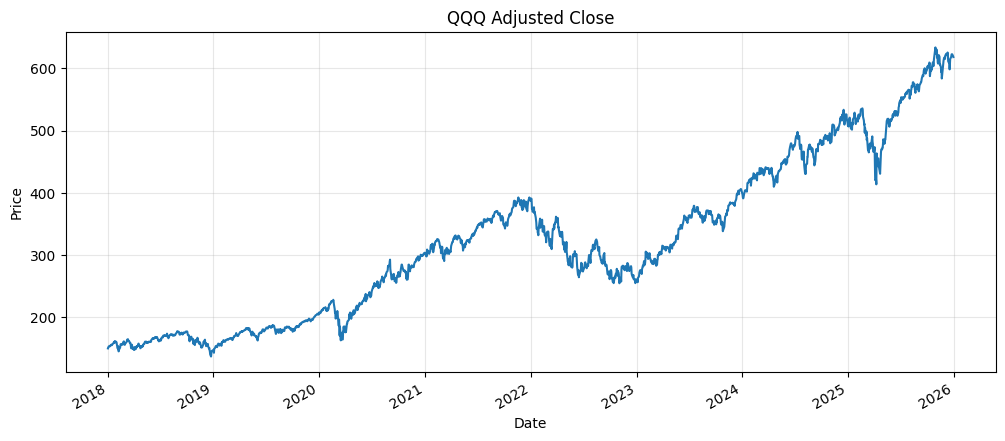

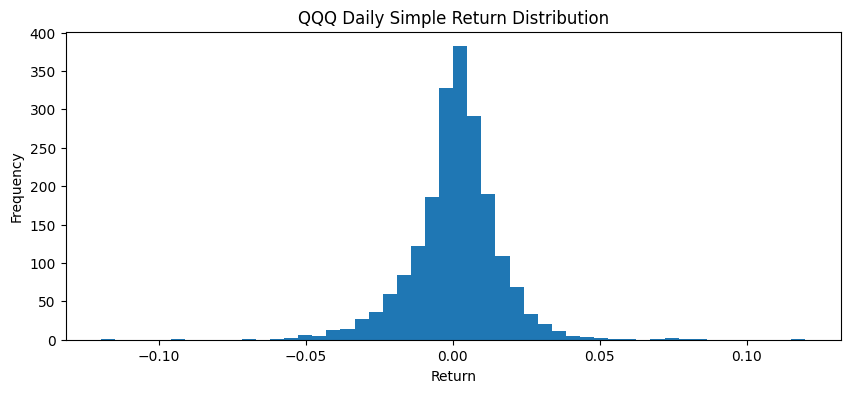

In [7]:
ticker = "QQQ"

plt.figure(figsize=(12, 5))
adj_close[ticker].plot()
plt.title(f"{ticker} Adjusted Close")
plt.xlabel("Date")
plt.ylabel("Price")
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(10, 4))
simple_returns[ticker].dropna().hist(bins=50)
plt.title(f"{ticker} Daily Simple Return Distribution")
plt.xlabel("Return")
plt.ylabel("Frequency")
plt.grid(False)
plt.show()


## 8. Compute a few simple statistics

A quick way to compare tickers is to look at daily volatility. This is not a full factor yet. It is just a simple way to get familiar with the data.


Daily Volatility:


Ticker
TSLA    0.040118
AAPL    0.019401
MSFT    0.017861
QQQ     0.015153
SPY     0.012260
dtype: float64


Annualized Volatility (assuming 252 trading days):


Ticker
TSLA    0.636846
AAPL    0.307982
MSFT    0.283531
QQQ     0.240550
SPY     0.194623
dtype: float64

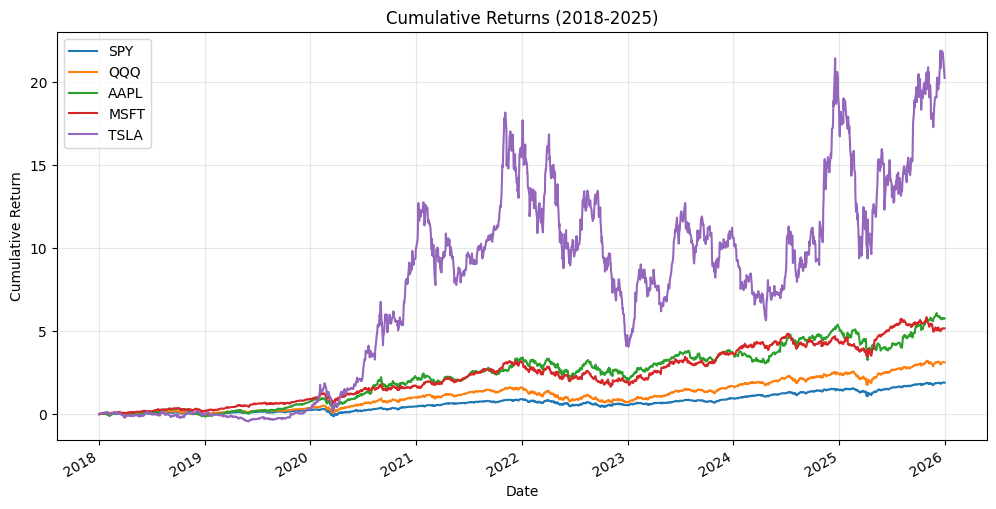

In [8]:
# Calculate daily volatility
daily_vol = simple_returns.std()
print("Daily Volatility:")
display(daily_vol.sort_values(ascending=False))

# Calculate and show annualized volatility
annualized_vol = daily_vol * np.sqrt(252)
print("\nAnnualized Volatility (assuming 252 trading days):")
display(annualized_vol.sort_values(ascending=False))

# Calculate cumulative returns
cumulative_returns = (1 + simple_returns.fillna(0)).cumprod() - 1

# Plot cumulative returns for all tickers
plt.figure(figsize=(12, 6))
for t in tickers:
    cumulative_returns[t].plot(label=t)
plt.title("Cumulative Returns (2018-2025)")
plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


## 9. Save a local sample dataset

If everything works, save one parquet file for later weeks. The file should go into `data/raw/` and should not be committed to Git.

If `pyarrow` is missing, this step will fail. Install it and run the cell again.


In [9]:
output_path = "../data/raw/week1_sample_prices.parquet"
adj_close.to_parquet(output_path)
output_path


'../data/raw/week1_sample_prices.parquet'

## 10. Notes & Reflection Questions (Day 5)

### 1. Does the dataset have missing values?
- **No.** The adjusted close prices for all 5 tickers (SPY, QQQ, AAPL, MSFT, TSLA) from 2018-01-02 to 2025-12-30 are fully populated (2010 rows) with no missing values (NaN).

### 2. Which ticker is the most volatile according to daily return std?
- **TSLA** is the most volatile ticker in the sample, with a daily return standard deviation of approximately **4.01%** (more than 3 times that of SPY at **1.23%**).

### 3. Do SPY and QQQ show similar patterns?
- **Yes.** Both SPY and QQQ exhibit highly correlated long-term growth and price movements (due to significant overlap in mega-cap technology holdings). However, QQQ features a higher daily volatility and higher cumulative return due to its tech-heavy focus.

### 4. Why is the return distribution of TSLA wider than SPY?
- **TSLA is a single growth stock** that is highly sensitive to company-specific news and speculation. In contrast, **SPY is a diversified ETF** holding 500 of the largest US companies. The diversification effect averages out extreme individual stock movements, resulting in a much narrower return distribution clustered tightly around 0.


## 11. Finish

If you finish this notebook, you have completed the foundation for Week 1 Day 2. The next step is to write short notes about OHLCV, adjusted close, simple return, and log return.
